In [ ]:
import os
import joblib

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss

import numpy as np
import matplotlib.pyplot as plt

import torch

## Datasets

In [16]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [30]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [31]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [32]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [33]:
all_params[cond][200:300, :][0]

tensor([-9.5093e-01,  3.0941e-01,  3.0941e-01,  9.5093e-01, -2.7855e-03,
         1.2105e-01,  9.3783e-02,  4.7615e-02,  5.4671e-03, -3.6905e-02,
        -2.9796e-02, -1.5231e-02,  1.2550e+00,  2.7655e-01,  1.7737e-01,
         1.2581e-01, -4.6742e-01,  6.4222e-01, -4.2880e-01, -2.7613e-01,
         2.8589e-03,  5.8668e-01, -1.4988e-02,  1.6313e-02,  1.3235e+00,
        -2.3746e+00,  2.2764e-02, -2.4062e-02, -7.5070e-01, -8.1643e-01,
        -9.2812e-05, -2.0547e-03, -6.1629e-01,  4.9528e-01, -1.0696e-04,
        -1.8437e-03, -1.2960e-01, -9.9638e-01, -4.7654e-01,  1.0237e-02,
         8.8038e-01,  3.6893e-02,  6.4792e-03, -3.8627e-03, -6.5069e-02,
        -8.9552e-01,  6.0627e-03,  2.5872e-02, -9.9657e-01,  9.1778e-02,
        -2.9557e-02, -5.9324e-01,  2.3991e-02, -9.9969e-01, -5.6615e-01,
        -4.0884e-02, -1.0148e+00, -2.4088e-02,  6.1714e-02,  9.5327e-03,
        -2.1625e-02, -1.1864e+00, -2.2994e-03, -9.5677e-03, -9.9948e-01,
         1.3841e-02,  1.4175e-02,  1.7388e-01,  9.3

In [34]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7475, std: 0.0057
C=0.1 , l1=0.5, mean: 0.7493, std: 0.0055
C=0.1 , l1=1.0, mean: 0.7511, std: 0.0036
C=1.0 , l1=0.0, mean: 0.7475, std: 0.0055
C=1.0 , l1=0.5, mean: 0.7474, std: 0.0057
C=1.0 , l1=1.0, mean: 0.7479, std: 0.0053
C=10.0, l1=0.0, mean: 0.7474, std: 0.0055
C=10.0, l1=0.5, mean: 0.7478, std: 0.0053
C=10.0, l1=1.0, mean: 0.7473, std: 0.0063


In [35]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7402, std: 0.0020
C=0.1 , l1=0.5, mean: 0.7400, std: 0.0020
C=0.1 , l1=1.0, mean: 0.7377, std: 0.0023
C=1.0 , l1=0.0, mean: 0.7397, std: 0.0021
C=1.0 , l1=0.5, mean: 0.7396, std: 0.0021
C=1.0 , l1=1.0, mean: 0.7398, std: 0.0021
C=10.0, l1=0.0, mean: 0.7395, std: 0.0018
C=10.0, l1=0.5, mean: 0.7397, std: 0.0021
C=10.0, l1=1.0, mean: 0.7396, std: 0.0023


### Accuracies on all datasets

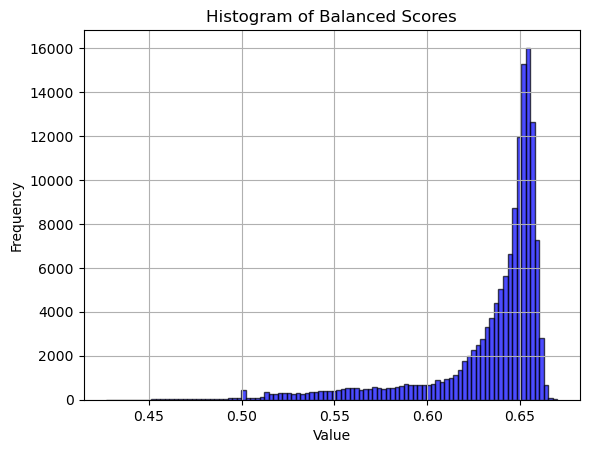

In [36]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

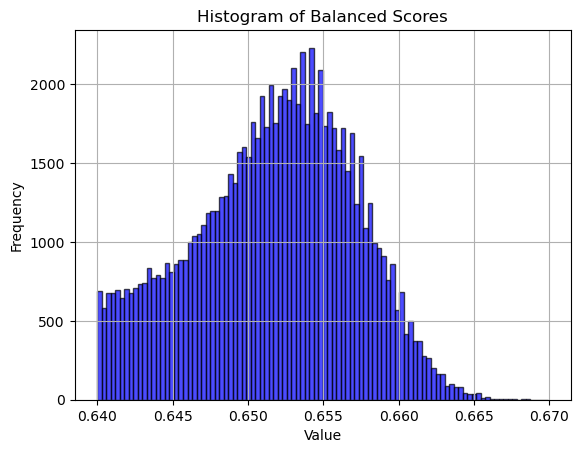

In [37]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [38]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [39]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [40]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.640127630479374

Confusion Matrix for Class 0 - Chowell_train:
[[0.74831001 0.25168999]
 [0.04878472 0.95121528]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.80009525 0.19990475]
 [0.12497363 0.87502637]]

Confusion Matrix for Class 2 - MSK1:
[[0.92570987 0.07429013]
 [0.45228149 0.54771851]]

Confusion Matrix for Class 3 - MSK2:
[[0.92696673 0.07303327]
 [0.67156287 0.32843713]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.94731304 0.05268696]
 [0.78758741 0.21241259]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[1. 0.]
 [1. 0.]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.98145406 0.01854594]
 [0.85618067 0.14381933]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.8830904  0.1169096 ]
 [0.50818966 0.49181034]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96578483 0.03421517]
 [0.68429574 0.31570426]]


              precision    recall  f1-score   support

           0       0.87      0.95      0.91     11520
           1       0.83      0.8

### Strong (AUC scores)

In [41]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [42]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.7159995684539864

Confusion Matrix for Class 0 - Chowell_train:
[[0.9547241  0.0452759 ]
 [0.00217014 0.99782986]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.95725682 0.04274318]
 [0.02699852 0.97300148]]

Confusion Matrix for Class 2 - MSK1:
[[0.92485202 0.07514798]
 [0.21706298 0.78293702]]

Confusion Matrix for Class 3 - MSK2:
[[0.95060665 0.04939335]
 [0.79357618 0.20642382]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.91890267 0.08109733]
 [0.5465472  0.4534528 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.96930212 0.03069788]
 [0.82383058 0.17616942]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.97989558 0.02010442]
 [0.81913629 0.18086371]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.96133223 0.03866777]
 [0.69913793 0.30086207]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96557319 0.03442681]
 [0.62385321 0.37614679]]


              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11520

## White-box attack ensemble

In [43]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [44]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.8635


In [45]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.7729570476042797

Confusion Matrix for Class 0 - Chowell_train:
[[0.9567678  0.0432322 ]
 [0.01024306 0.98975694]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.92213359 0.07786641]
 [0.05072769 0.94927231]]

Confusion Matrix for Class 2 - MSK1:
[[0.94303852 0.05696148]
 [0.20501285 0.79498715]]

Confusion Matrix for Class 3 - MSK2:
[[0.97080235 0.02919765]
 [0.18155112 0.81844888]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.94175122 0.05824878]
 [0.59921329 0.40078671]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.97600118 0.02399882]
 [0.86083314 0.13916686]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.96805112 0.03194888]
 [0.79992076 0.20007924]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94365984 0.05634016]
 [0.575      0.425     ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96282187 0.03717813]
 [0.34106854 0.65893146]]


              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11520

### Evaluate LORIS

In [94]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [95]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [96]:
classify_by_dataset(loaded_models, X_loris)

ValueError: X has 22 features, but MLPClassifier is expecting 168 features as input.

### Check other models

In [97]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([182, 168])


tensor([[ 4.3077e-01, -9.0246e-01, -9.0246e-01, -4.3077e-01, -2.7213e-02,
          4.9116e-02,  2.8638e-02,  4.1941e-02,  6.2589e-02, -9.3703e-02,
         -5.8263e-02, -8.5923e-02,  3.9584e-01, -1.4459e+00,  1.7448e-01,
         -1.2895e-01,  7.9254e-01, -9.8557e-02, -2.0988e-01,  1.9840e-01,
         -7.3212e-01,  2.2098e+00, -2.1597e-02,  3.3243e-02,  1.3975e-01,
          8.4986e-01, -2.0778e-02,  3.3883e-02, -1.1027e+00, -2.2707e-01,
         -5.1051e-03, -8.8153e-03, -1.1966e-01,  7.3868e-01, -3.5289e-03,
         -5.6629e-03,  5.4680e-01, -6.7435e-01, -3.8176e-01, -4.1167e-01,
          2.6055e-01,  1.0562e+00,  1.9582e-01,  1.9223e-01,  5.8632e-01,
         -6.8858e-01,  1.8055e-01,  6.8180e-01, -7.8627e-01, -3.5139e-01,
         -9.2125e-02, -4.2185e-01, -8.4888e-01,  6.0116e-01, -3.3826e-01,
         -2.2550e-01, -1.1300e+00, -1.0409e+00,  1.2263e-01,  7.0441e-02,
          8.9626e-01, -5.5605e-01, -3.8174e-02,  7.9345e-02, -4.7150e-01,
         -9.2019e-01,  5.9639e-02, -1.

In [98]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0395
            MSK1: 0.2277
            MSK2: 0.0201
      Shim_NSCLC: 0.7535
  Kato_panCancer: 0.5323
   Vanguri_NSCLC: 0.4500
      Ravi_NSCLC: 0.7118
Pradat_panCancer: 0.1038
